AVANCE 3 

Analizar los datos integrados (clientes, Yelp, tendencias externas) para identificar patrones relevantes que puedan guiar decisiones de marketing. Formular preguntas clave del negocio y responderlas con visualizaciones y análisis descriptivo. Encontrarás a continuación algunas guías posibles:

In [1]:
#Importamos las librerias y csvs correspondientes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
    
df_clientes = pd.read_csv(r"C:/Users/Enzo/OneDrive/Escritorio/Data Science Henry/P1/ProyectoM1_ZambonEnzo/df_clientes_boston.csv")
df_rest = pd.read_csv(r"C:/Users/Enzo/OneDrive/Escritorio/Data Science Henry/P1/ProyectoM1_ZambonEnzo/df_rest_boston.csv")

VISUALIZACIONES Y ANALISIS DESCRIPTIVO

In [2]:
df_clientes

,id_persona,cliente,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,4013002847,James Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
1,8373803828,Julie Russo,66.0,Femenino,Boston,Muy Alto,9,19.94,No,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,13456
2,5394273061,Sara Ball,37.0,Femenino,Boston,Bajo,1,11.35,Sí,No,Carnes,No,563-346-4749x6591,smithstacy@example.com,Efectivo,1197
3,9336353877,Mary Bentley,29.0,Femenino,Boston,Medio,2,11.22,No,Sí,Vegetariano,No,6382528579,NaN,Efectivo,2052
4,1232293617,Elizabeth Griffin,51.0,Femenino,Boston,Alto,6,51.46,No,No,Vegetariano,Sí,906.282.9481,NaN,Efectivo,8499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,9954331046,Joseph Bradford,71.0,Masculino,Boston,Alto,5,28.61,Sí,No,Vegetariano,Sí,NaN,slopez@example.org,Efectivo,8573
2405,5640389791,Sandra Patterson,44.0,Femenino,Boston,Muy Alto,8,55.11,No,Sí,Vegetariano,Sí,001-641-556-2038,NaN,Tarjeta,15402
2406,4256494771,Paul Avila,39.0,Masculino,Boston,Medio,2,30.48,Sí,No,Carnes,No,NaN,NaN,Tarjeta,3184
2407,3757092338,Ronald Myers,70.0,Masculino,Boston,Muy Alto,6,43.45,Sí,Sí,Carnes,Sí,+1-770-899-2418x07194,judith11@example.com,Efectivo,14732


GRAFICOS DE LA BASE DE CLIENTES

In [3]:
#Vamos a ordenar algunas categoricas en función de los estratos socioeconomicos. Para ello es útil ordenarlos bajo una logica adecuada:
orden_estratos = ["Bajo",  "Medio", "Alto", "Muy Alto"]

# Convertir columna a tipo Categorical con orden
df_clientes['estrato_socioeconomico'] = pd.Categorical(
    df_clientes['estrato_socioeconomico'],
    categories=orden_estratos,
    ordered=True
)

# Ordenamos el Dataframe por estrato
df_clientes = df_clientes.sort_values('estrato_socioeconomico')

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\1735926333.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = df_clientes.groupby(['estrato_socioeconomico','genero']).size().unstack(fill_value=0)


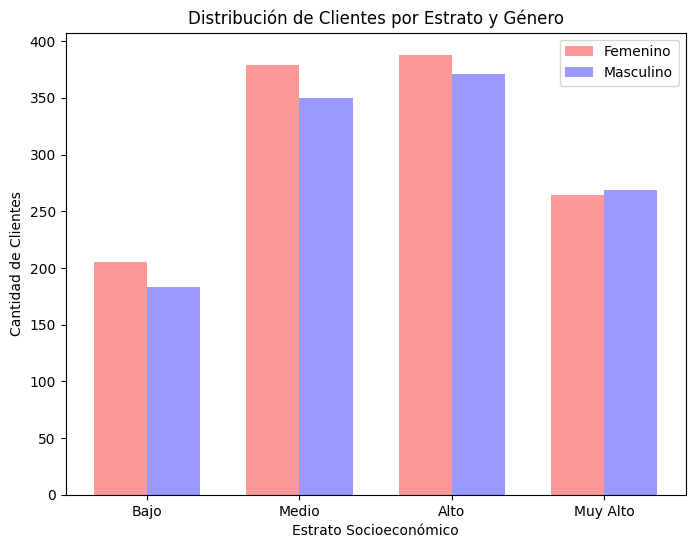

In [4]:
#El primer grafico consiste en uno de barras comparativas entre el genero del cliente por estato socioeconomico

tabla = df_clientes.groupby(['estrato_socioeconomico','genero']).size().unstack(fill_value=0)

x = np.arange(len(tabla.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x - width/2, tabla['Femenino'], width, label='Femenino', color='#FF9999')
ax.bar(x + width/2, tabla['Masculino'], width, label='Masculino', color='#9999FF')
ax.set_xlabel('Estrato Socioeconómico')
ax.set_ylabel('Cantidad de Clientes')   
ax.set_title('Distribución de Clientes por Estrato y Género')
ax.set_xticks(x)
ax.set_xticklabels(tabla.index)
ax.legend()

plt.show()

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\1809166138.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promedio_gasto = df_clientes.groupby('estrato_socioeconomico')['promedio_gasto_comida'].mean()


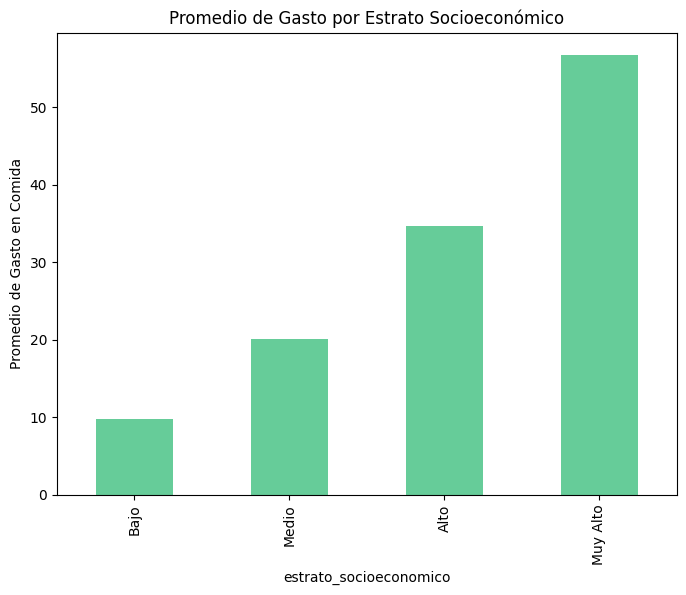

In [5]:
#Tambien podemos distribuir el promedio de gasto por estrato

promedio_gasto = df_clientes.groupby('estrato_socioeconomico')['promedio_gasto_comida'].mean()
promedio_gasto.plot(kind='bar', figsize=(8,6), color='#66CC99')
plt.ylabel('Promedio de Gasto en Comida')
plt.title('Promedio de Gasto por Estrato Socioeconómico')
plt.show()

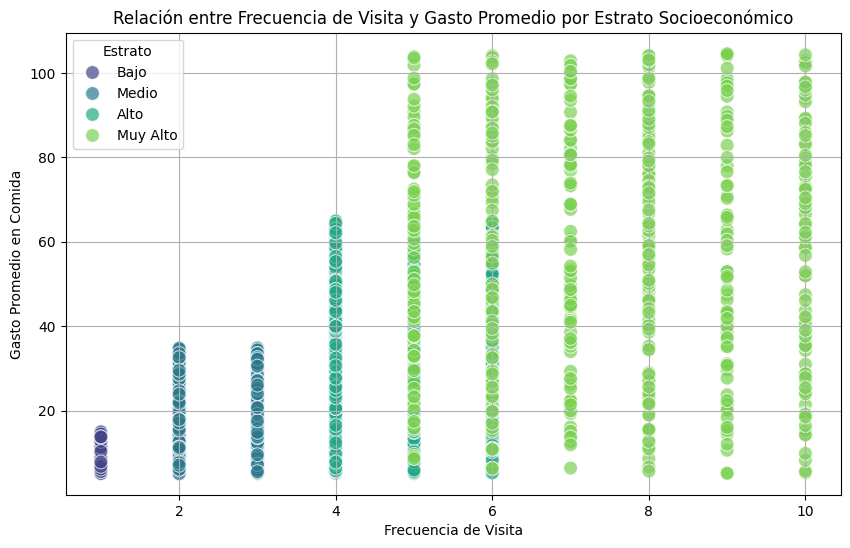

In [6]:
#Se puede establecer cierta relación entre el gasto promedio y la frecuencia de visita, tambien dividia por estato socioeconomico

df_clientes['estrato_socioeconomico'] = pd.Categorical(df_clientes['estrato_socioeconomico'], categories=orden_estratos, ordered=True)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_clientes,
    x='frecuencia_visita',
    y='promedio_gasto_comida',
    hue='estrato_socioeconomico',  
    palette='viridis',
    s=100,                         
    alpha=0.7
)
plt.xlabel('Frecuencia de Visita')
plt.ylabel('Gasto Promedio en Comida')
plt.title('Relación entre Frecuencia de Visita y Gasto Promedio por Estrato Socioeconómico')
plt.legend(title='Estrato')
plt.grid(True)
plt.show()

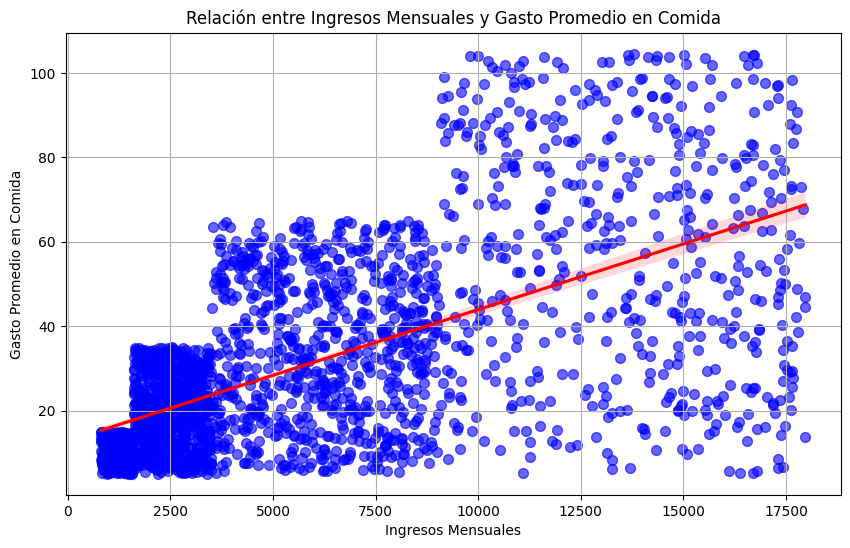

In [7]:
#Tambien observamos la correlación entre los ingresos y el gasto promedio en comida
plt.figure(figsize=(10,6))
sns.regplot(
    data=df_clientes,
    x='ingresos_mensuales',
    y='promedio_gasto_comida',
    scatter_kws={'alpha':0.6, 'color':'blue', 's':50},
    line_kws={'color':'red'}                           
)
plt.xlabel('Ingresos Mensuales')
plt.ylabel('Gasto Promedio en Comida')
plt.title('Relación entre Ingresos Mensuales y Gasto Promedio en Comida')
plt.grid(True)
plt.show()

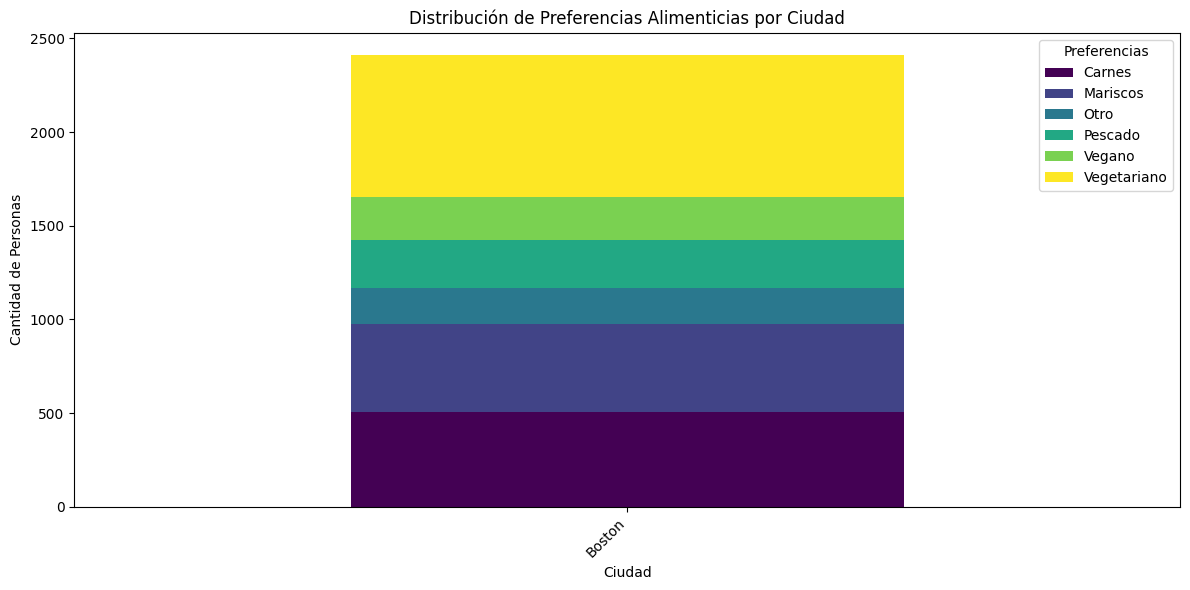

In [8]:
#A partir de un grafico de columna apilada podemos ver la proporcion de preferencias de comida en la ciudad de Boston
pref_ciudad = df_clientes.groupby(['ciudad_residencia', 'preferencias_alimenticias']).size().unstack(fill_value=0)
pref_ciudad.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)
plt.ylabel('Cantidad de Personas')
plt.xlabel('Ciudad')
plt.title('Distribución de Preferencias Alimenticias por Ciudad')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Preferencias')
plt.tight_layout()
plt.show()

preferencias_alimenticias
Vegetariano    70
Carnes         57
Mariscos       47
Vegano         26
Pescado        24
Otro           17
Name: count, dtype: int64


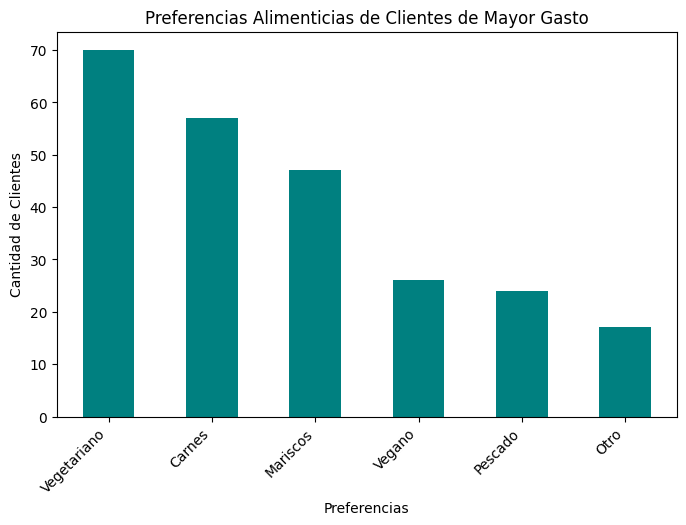

In [9]:
#Tambien podemos ver las preferencias de comida de aquellos clientes con mayor gasto en comida

umbral = df_clientes['promedio_gasto_comida'].quantile(0.9)
clientes_top = df_clientes[df_clientes['promedio_gasto_comida'] >= umbral]

preferencias_top = clientes_top['preferencias_alimenticias'].value_counts()
print(preferencias_top)
preferencias_top.plot(kind='bar', figsize=(8,5), color='teal')
plt.title('Preferencias Alimenticias de Clientes de Mayor Gasto')
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Preferencias')
plt.xticks(rotation=45, ha='right')
plt.show()

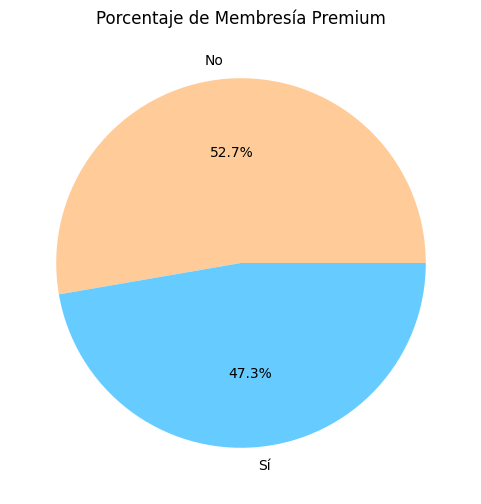

In [10]:
#Tambien podemos distribuir la proporcion de clientes entre aquellos que tienen membresia premium y los que no
df_clientes['membresia_premium'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=['#FFCC99','#66CCFF'])
plt.title('Porcentaje de Membresía Premium')
plt.ylabel('')
plt.show()

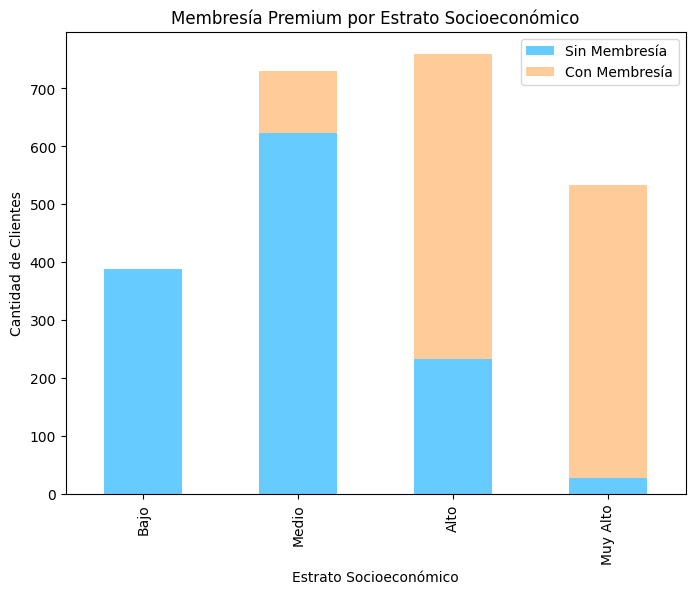

In [11]:
pd.crosstab(df_clientes['estrato_socioeconomico'], df_clientes['membresia_premium'])

pd.crosstab(df_clientes['estrato_socioeconomico'], df_clientes['membresia_premium']) \
  .plot(kind='bar', stacked=True, figsize=(8,6), color=['#66CCFF','#FFCC99'])

plt.title('Membresía Premium por Estrato Socioeconómico')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Cantidad de Clientes')
plt.legend(['Sin Membresía','Con Membresía'])
plt.show()

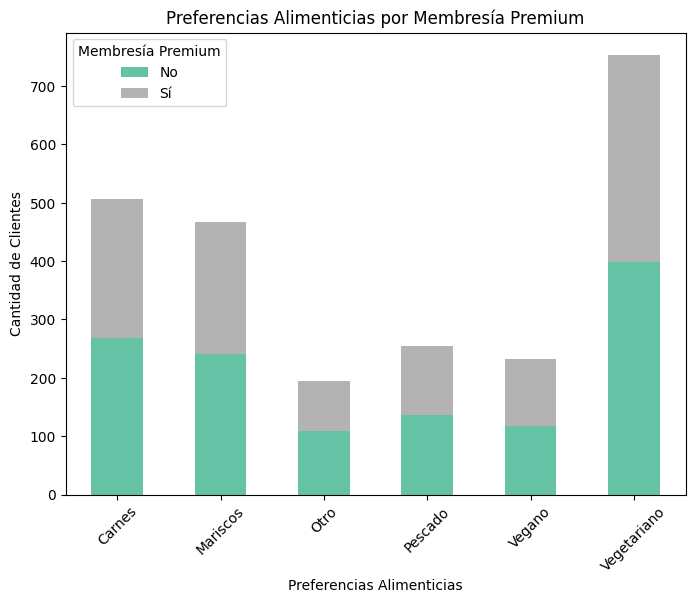

In [12]:
pref_membresia = pd.crosstab(df_clientes['preferencias_alimenticias'], 
                             df_clientes['membresia_premium'])

pref_membresia.plot(kind='bar', stacked=True, figsize=(8,6), colormap="Set2")

plt.title('Preferencias Alimenticias por Membresía Premium')
plt.xlabel('Preferencias Alimenticias')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Membresía Premium')
plt.xticks(rotation=45)
plt.show()

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\2876891571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


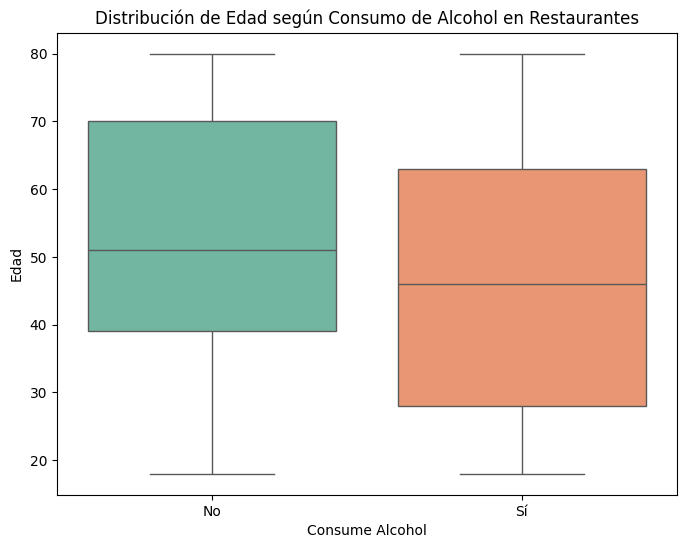

In [13]:
#Se distribuye en el siguiente grafico el consumo de alcohol en función de la edad de los clientes
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_clientes,
    x='consume_licor',
    y='edad',
    palette='Set2'
)
plt.title('Distribución de Edad según Consumo de Alcohol en Restaurantes')
plt.xlabel('Consume Alcohol')
plt.ylabel('Edad')
plt.show()

In [14]:
#Creamos rangos de edad para visualizar mejor el comportamiento a partir de esta variable
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']

df_clientes['estrato_edad'] = pd.cut(df_clientes['edad'], bins=bins, labels=labels, right=False)

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\3198097312.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_pref = df_clientes.groupby(['estrato_edad', 'preferencias_alimenticias']).size().unstack(fill_value=0)


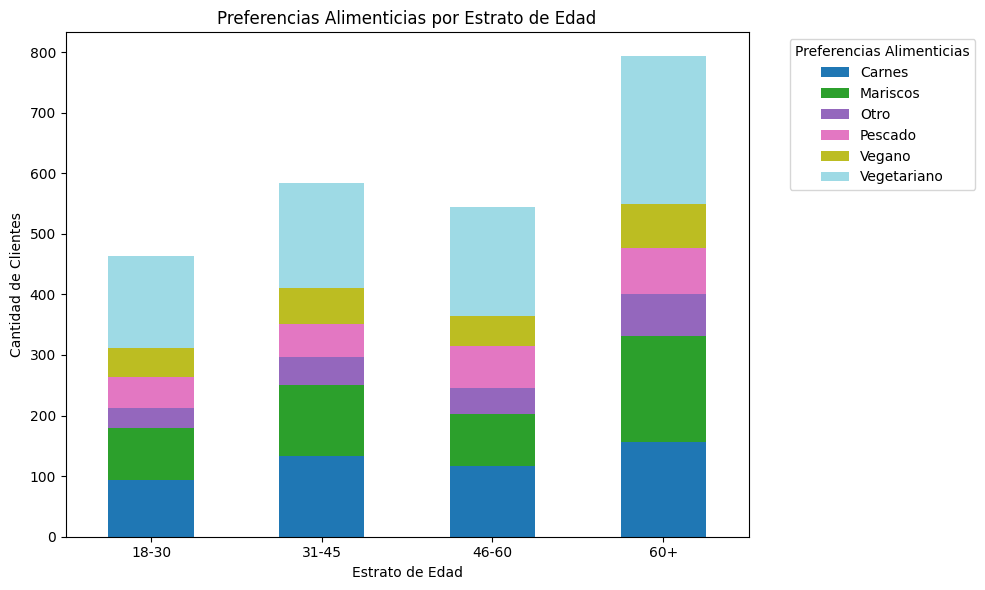

In [15]:
#Distribuimos las preferencias por estrato de edad

tabla_pref = df_clientes.groupby(['estrato_edad', 'preferencias_alimenticias']).size().unstack(fill_value=0)
tabla_pref

tabla_pref.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

plt.title('Preferencias Alimenticias por Estrato de Edad')
plt.xlabel('Estrato de Edad')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Preferencias Alimenticias', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\436290945.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_visita = df_clientes.groupby(['estrato_edad', 'frecuencia_visita']).size().unstack(fill_value=0)


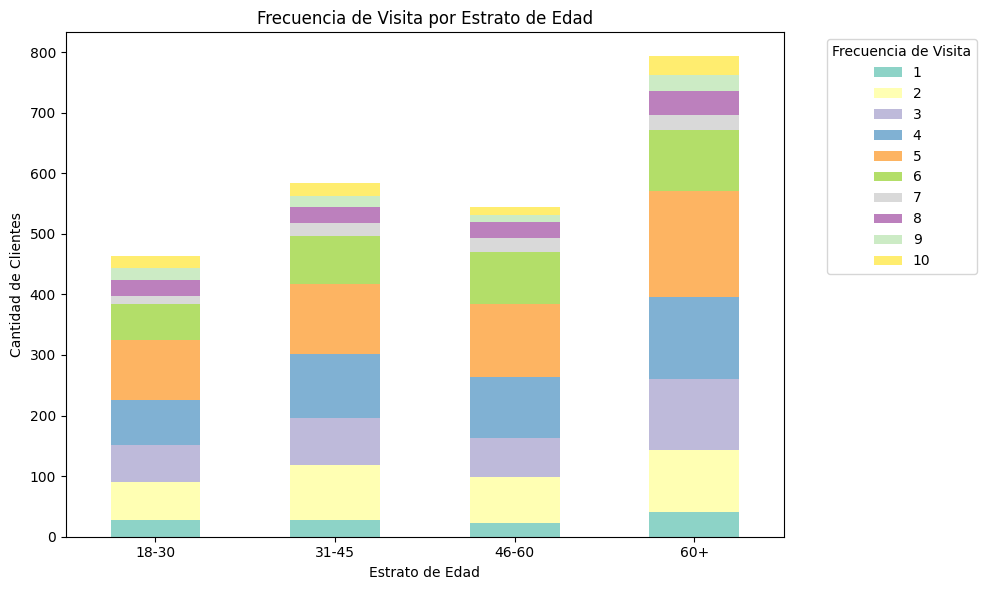

In [16]:
#Lo mismo hacemos con la frecuencia de visita
tabla_visita = df_clientes.groupby(['estrato_edad', 'frecuencia_visita']).size().unstack(fill_value=0)
tabla_visita
tabla_visita.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set3')
plt.title('Frecuencia de Visita por Estrato de Edad')
plt.xlabel('Estrato de Edad')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Frecuencia de Visita', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

GRAFICOS DE LA BASE DE RESTAURANTES

In [17]:
df_rest.head()

,id,alias,name,url,review_count,categories,rating,coordinates,transactions,price,location,phone,display_phone,distance,price_num
0,kP1b-7BO_VhWk_0tvuA_tw,carmelinas-boston-2,Carmelina's,https://www.yelp.com/biz/carmelinas-boston-2?a...,4126,"[{'alias': 'italian', 'title': 'Italian'}]",4.5,"{'latitude': 42.36388, 'longitude': -71.05415}","['restaurant_reservation', 'delivery']",$$$,"{'address1': '307 Hanover St', 'address2': '',...",1.617742e+10,(617) 742-0020,2272.117192,3.0
1,sA2gVTJOBH7Qk32p48ENdQ,saltie-girl-boston,Saltie Girl,https://www.yelp.com/biz/saltie-girl-boston?ad...,2500,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",4.2,"{'latitude': 42.35116, 'longitude': -71.07758}","['pickup', 'delivery']",$$$,"{'address1': '279 Dartmouth St', 'address2': '...",1.617267e+10,(617) 267-0691,638.213544,3.0
2,xh-i6tYmojnnUHrnkFnWdA,willow-and-ivy-boston,Willow & Ivy,https://www.yelp.com/biz/willow-and-ivy-boston...,31,"[{'alias': 'newamerican', 'title': 'New Americ...",4.7,"{'latitude': 42.349126, 'longitude': -71.079754}",[],NaN,"{'address1': '65 Exeter St', 'address2': None,...",1.617933e+10,(617) 933-4800,713.579578,3.0
3,t_FFcwUutj9mIYKGw_gHsQ,the-salty-pig-boston,The Salty Pig,https://www.yelp.com/biz/the-salty-pig-boston?...,2040,"[{'alias': 'newamerican', 'title': 'New Americ...",4.2,"{'latitude': 42.3469, 'longitude': -71.076121}",['delivery'],$$,"{'address1': '130 Dartmouth St', 'address2': '...",1.617537e+10,(617) 536-6200,414.307221,2.0
4,JYoptTywH42iRjMaE925BA,isabella-ristorante-boston,Isabella Ristorante,https://www.yelp.com/biz/isabella-ristorante-b...,571,"[{'alias': 'italian', 'title': 'Italian'}]",4.5,"{'latitude': 42.36403, 'longitude': -71.05362}",[],$$,"{'address1': '2 Prince St', 'address2': '', 'a...",1.617228e+10,(617) 227-7300,2311.555147,3.0


C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\2866795016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_num', data=df_rest, palette='viridis')


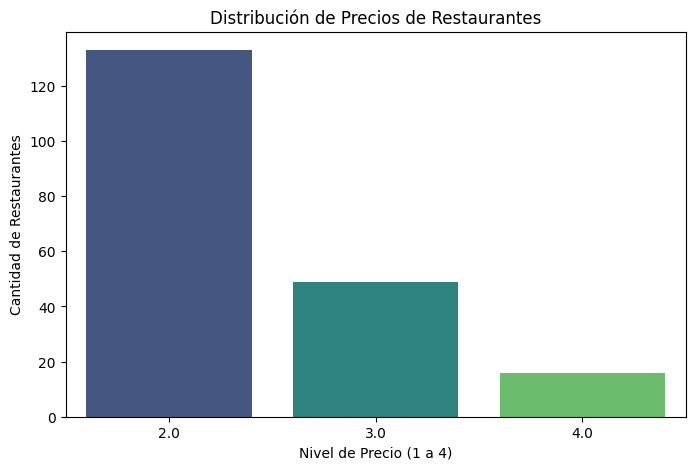

In [18]:
#Para los restaurantes, distribuimos los mismos de acuerdo a su nivel de precios
plt.figure(figsize=(8,5))
sns.countplot(x='price_num', data=df_rest, palette='viridis')
plt.title('Distribución de Precios de Restaurantes')
plt.xlabel('Nivel de Precio (1 a 4)')
plt.ylabel('Cantidad de Restaurantes')
plt.show()

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\4168412194.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


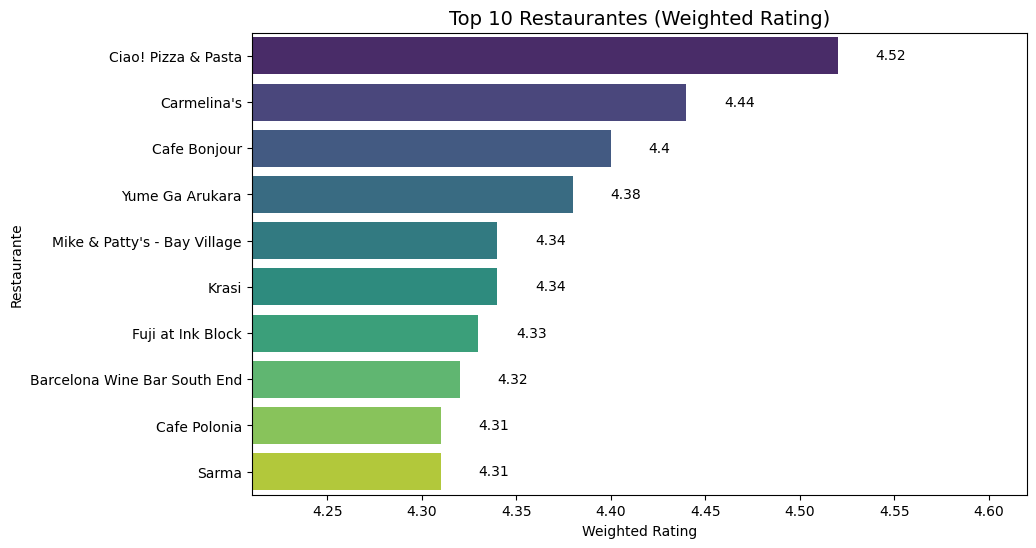

In [19]:
import ast

df_rest['categories'] = df_rest['categories'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df_rest['categories_clean'] = df_rest['categories'].apply(lambda x: ', '.join([d['title'] for d in x]) if isinstance(x, list) else '')

C = df_rest['rating'].mean()
m = df_rest['review_count'].quantile(0.80)

def weighted_rating(x, m=m, C=C):
    v = x['review_count']
    R = x['rating']
    return (v / (v + m)) * R + (m / (v + m)) * C

df_rest['weighted_rating'] = df_rest.apply(weighted_rating, axis=1).round(2)
df_rest_sorted = df_rest.sort_values('weighted_rating', ascending=False)
df_rest_sorted[['name', 'rating', 'review_count', 'weighted_rating']].head(10)
top10 = df_rest_sorted.head(10)


plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x="weighted_rating", 
    y="name", 
    palette="viridis"
)

plt.title("Top 10 Restaurantes (Weighted Rating)", fontsize=14)
plt.xlabel("Weighted Rating")
plt.ylabel("Restaurante")
plt.xlim(top10['weighted_rating'].min() - 0.1, top10['weighted_rating'].max() + 0.1)
for i, v in enumerate(top10["weighted_rating"]):
    plt.text(v + 0.02, i, str(v), va="center")

plt.show()

C:\Users\Enzo\AppData\Local\Temp\ipykernel_17796\2944458976.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cats, x='cantidad', y='categories_list', palette="viridis")


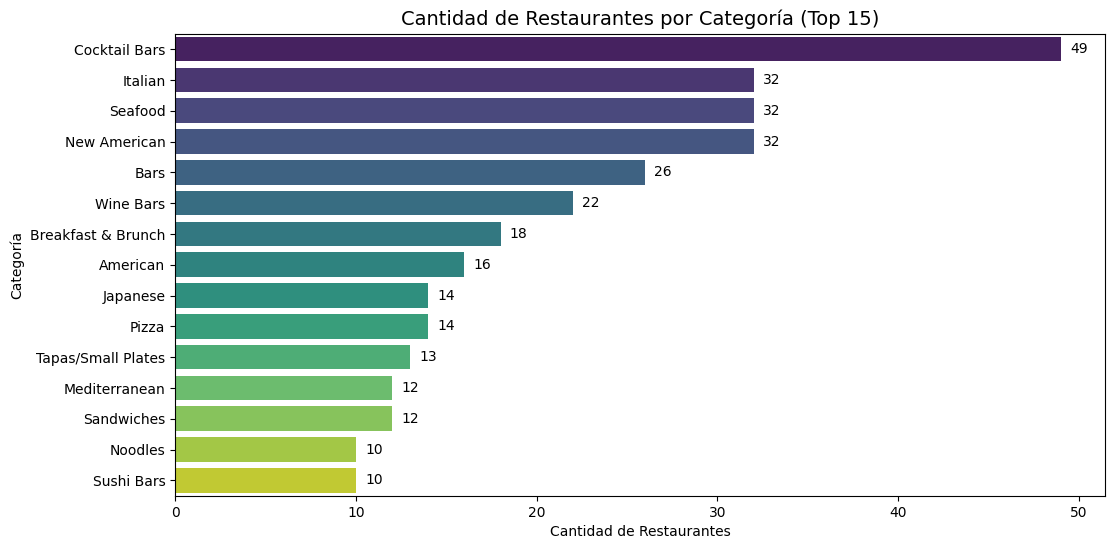

In [20]:
df_rest['categories'] = df_rest['categories'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_rest['categories_list'] = df_rest['categories'].apply(
    lambda x: [d['title'] for d in x] if isinstance(x, list) else []
)


df_exploded = df_rest.explode('categories_list')
cat_stats = (
    df_exploded.groupby('categories_list')
    .agg(
        cantidad=('id', 'count'),
        avg_weighted_rating=('weighted_rating', 'mean')
    )
    .reset_index()
    .sort_values('cantidad', ascending=False)
)

top_cats = cat_stats.head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=top_cats, x='cantidad', y='categories_list', palette="viridis")
plt.title("Cantidad de Restaurantes por Categoría (Top 15)", fontsize=14)
plt.xlabel("Cantidad de Restaurantes")
plt.ylabel("Categoría")

for i, v in enumerate(top_cats['cantidad']):
    plt.text(v + 0.5, i, str(v), va='center')

plt.show()

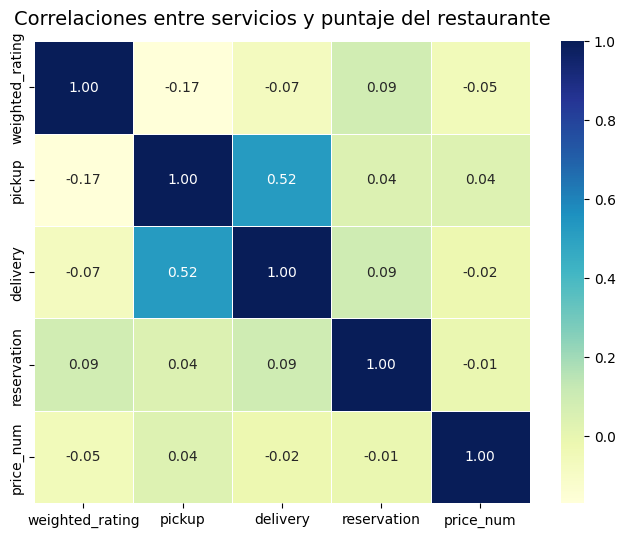

In [21]:

df_rest['pickup'] = df_rest['transactions'].apply(lambda x: 1 if 'pickup' in x else 0)
df_rest['delivery'] = df_rest['transactions'].apply(lambda x: 1 if 'delivery' in x else 0)
df_rest['reservation'] = df_rest['transactions'].apply(lambda x: 1 if 'restaurant_reservation' in x else 0)

df_rest_sorted['pickup'] = df_rest['transactions'].apply(lambda x: 1 if 'pickup' in x else 0)
df_rest_sorted['delivery'] = df_rest['transactions'].apply(lambda x: 1 if 'delivery' in x else 0)
df_rest_sorted['reservation'] = df_rest['transactions'].apply(lambda x: 1 if 'restaurant_reservation' in x else 0)

df_rest_sorted[['name', 'categories_clean', 'weighted_rating', 
                'pickup', 'delivery', 'reservation','price_num']]

cols = ['weighted_rating', 'pickup', 'delivery', 'reservation', 'price_num']
corr = df_rest_sorted[cols].corr()

# Creamos el heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="YlGnBu", linewidths=0.5, fmt=".2f")
plt.title("Correlaciones entre servicios y puntaje del restaurante", fontsize=14, pad=12)
plt.show()

ESTABLECER RELACIONES ENTRE LOS DOS DATAFRAMES

Esto se hizo a partir de establecer las siguientes relaciones entre variables:

      # Factor 1: Compatibilidad económica (30%): relaciona el estrato socioeconómico con el nivel de precios del restaurante

      # Factor 2: Compatibilidad alimentaria (50%): evalua la compatibilidad de las preferencias del cliente con la categorias del restaurante

      # Factor 3: Calidad del restaurante (20%): Evalua la calidad de los mismos en función del rating y el score_review

In [22]:
#FACTOR DE COMPATIBILIDAD ECONÓMICA:

df_rest["price_num"] = df_rest["price_num"].astype("Int64")

def puede_pagar(estrato_socioeconomico, price_nume): # Cambié el nombre del parámetro a price_nume para evitar confusión con la columna del DataFrame
    compatibilidad = { # Diccionario que define la compatibilidad entre estrato socioeconómico y nivel de precio
        'Bajo': {'1': 0.5, '2': 0.3, '3': 0.2, '4': 0.0},
        'Medio': {'1': 0.2, '2': 0.5, '3': 0.2, '4': 0.1},
        'Alto': {'1': 0.1, '2': 0.2, '3': 0.5, '4': 0.2},
        'Muy Alto': {'1': 0.0, '2': 0.2, '3': 0.3, '4': 0.5}
    }
    
    price_str = str(price_nume) # Convertir price_nume a cadena para buscar en el diccionario
    
    return compatibilidad.get(estrato_socioeconomico, {}).get(price_str, 0.0) 
# Obtener la compatibilidad, devolviendo 0.0 si no se encuentra el estrato o el nivel de precio

In [23]:
#FACTOR DE COMPATIBILIDAD ALIMENTARIA:

# Crear nueva columna con formato entre corchetes
df_rest['categories_list'] = df_rest['categories'].apply(
    lambda x: [c['title'] for c in ast.literal_eval(x)] if isinstance(x, str) else [c['title'] for c in x]
)

def le_gusta_comida(preferencia_cliente, categoria_restaurante): # Función para evaluar si la categoría del restaurante coincide con la preferencia del cliente
    
    mapeo = { # Diccionario que mapea las preferencias del cliente a listas de categorías de restaurantes
    'Carnes': ['chicken_wings', 'cajun', 'steak', 'bbq', 'burgers', 'chickenshop', 'argentine', 'southern', 'newamerican', 'spanish', 'kebab', 'latin', 
               'delis', 'comfortfood', 'caribbean', 'polish', 'venezuelan', 'sandwiches', 'tapas', 'tradamerican', 'australian', 'halal', 'mexican', 'korean', 
               'chinese', 'filipino', 'tacos', 'sardinian', 'modern_european', 'french',  'hotpot', 'turkish', 'german', 'british', 'gastropubs', 'tapasmallplates', 
               'diners'],

    'Mariscos': ['seafood', 'fishnchips'],

    'Vegetariano': ['vietnamese', 'noodles', 'mideastern', 'cambodian', 'asianfusion', 'thai', 'lebanese', 'indpak', 'soup', 'salad', 'himalayan', 
                    'mediterranean', 'vegetarian', 'falafel', 'malaysian', 'singaporean', 'african'],

    'Otro': ['pastashops','italian', 'pizza', 'speakeasies', 'gourmet', 'restaurants', 'whiskeybars', 'desserts', 'icecream', 'bakeries', 'beerbar', 'cafes', 
             'intlgrocery', 'cocktailbars', 'coffee', 'wine_bars', 'lounges', 'beer_and_wine', 'pubs', 'venues', 'tikibars', 'breweries', 'brewpubs',
               'supperclubs', 'karaoke', 'bars', 'food_court', 'brasseries'],

    'Pescado': ['sushi', 'peruvian', 'dimsum', 'japanese', 'izakaya', 'ramen', 'poke', 'hainan', 'japacurry'],
    
    'Vegano': ['taiwanese', 'somali', 'piadina']
    }
    
    pref = str(preferencia_cliente).lower() # Convertir la preferencia del cliente a minúsculas para comparación insensible a mayúsculas
    
    # Buscar la mejor coincidencia entre todas las categorías del restaurante
    mejor_score = 0.0
    
    # Si categoria_restaurante es una lista
    if isinstance(categoria_restaurante, list): # Verificar si es una lista
        categorias_rest = [str(cat).lower() for cat in categoria_restaurante] # Convertir cada categoría a minúsculas
    else:
        categorias_rest = [str(categoria_restaurante).lower()] # Si no es una lista, convertir a minúsculas y poner en una lista
    
    # Buscar coincidencias
    for pref_key, cat_list in mapeo.items(): # Iterar sobre cada par clave-valor en el mapeo
        if pref_key.lower() in pref: # Comparar la clave del mapeo con la preferencia del cliente
            for categoria in cat_list: # Iterar sobre las categorías asociadas a esa clave
                for cat_rest in categorias_rest: # Iterar sobre las categorías del restaurante
                    if categoria in cat_rest: # Comparar la categoría del mapeo con la categoría del restaurante
                        mejor_score = max(mejor_score, 0.6) # Si hay coincidencia, asignar un score alto (0.6)
    
    # Si no hay coincidencia exacta, dar puntuación baja
    return mejor_score if mejor_score > 0 else 0.4

In [24]:
#FACTOR DE CALIDAD DEL RESTAURANTE:

def calcular_calidad(rating, review_count): # Función para calcular la calidad del restaurante basada en rating y número de reseñas 
    
    # Normalizar rating (0-1)
    rating_norm = rating / 5.0
    
    # Normalizar popularidad (0-1)
    popularidad_norm = min(review_count / 1000, 1.0)
    
    # Combinar: 70% rating, 30% popularidad
    calidad_final = (rating_norm * 0.3) + (popularidad_norm * 0.7)
    return calidad_final

In [25]:
#FUNCIÓN QUE INTEGRA TODOS LOS PARAMETROS Y GENERA UNA RECOMENDACIÓN A PARTIR DE PONDERACIONES A CADA PARÁMETRO

def recomendar_restaurantes(cliente_id, top_n=5):
    # 1. Obtener datos del cliente
    cliente = df_clientes[df_clientes['id_persona'] == cliente_id].iloc[0]
    
    # 2. Para cada restaurante, calcular score total
    scores = []
    
    for _, restaurante in df_rest.iterrows():
        # Factor 1: Compatibilidad económica (30%)
        score_precio = puede_pagar(cliente['estrato_socioeconomico'], 
                                       restaurante['price_num'])
        
        # Factor 2: Compatibilidad alimentaria (50%)
        score_comida = le_gusta_comida(cliente['preferencias_alimenticias'], 
                                      restaurante['categories_list'])
        
        # Factor 3: Calidad del restaurante (20%)
        score_calidad = calcular_calidad(restaurante['rating'], 
                                        restaurante['review_count'])
        # Score final ponderado
        score_total = (score_precio * 0.3) + (score_comida * 0.5) + (score_calidad * 0.2)
        
        scores.append({
            'restaurante': restaurante.get('alias', 'Sin nombre'),
            'categorias': restaurante['categories_list'],
            "estrato cliente": cliente['estrato_socioeconomico'],
            'preferencias_cliente': cliente['preferencias_alimenticias'],
            "recomendado": score_total,
        })
    
    # 3. Ordenar por score y devolver top N
    scores_df = pd.DataFrame(scores)
    top_recommendations = scores_df.nlargest(top_n, 'recomendado')
    
    return top_recommendations

EVALUACIÓN DEL MODELO DE RECOMENDACIÓN:

Caso 1: Cliente con estrato "Muy Alto" y preferencias "Vegetariano"

In [26]:
recomendaciones = recomendar_restaurantes(cliente_id=8373803828)
print("Top 5 restaurantes recomendados:")
display(recomendaciones)

Top 5 restaurantes recomendados:


,restaurante,categorias,estrato cliente,preferencias_cliente,recomendado
89,lukes-lobster-back-bay-boston,"[Seafood, Soup, Sandwiches]",Muy Alto,Vegetariano,0.64040
176,greco-boston-12,"[Greek, Salad, Soup]",Muy Alto,Vegetariano,0.59618
22,oleana-restaurant-cambridge,[Mediterranean],Muy Alto,Vegetariano,0.58160
64,mistral-boston,"[French, Mediterranean]",Muy Alto,Vegetariano,0.58040
115,committee-boston,"[Mediterranean, Greek, Cocktail Bars]",Muy Alto,Vegetariano,0.57106


Caso 2: Cliente con estrato "Bajo" y preferencias "Carne"

In [27]:
recomendaciones = recomendar_restaurantes(cliente_id=5394273061)
print("Top 5 restaurantes recomendados:")
display(recomendaciones)

Top 5 restaurantes recomendados:


,restaurante,categorias,estrato cliente,preferencias_cliente,recomendado
11,cafe-bonjour-boston,"[Breakfast & Brunch, Coffee & Tea, Sandwiches]",Bajo,Carnes,0.5852
14,barcelona-wine-bar-south-end-boston-6,"[Spanish, Wine Bars, Tapas/Small Plates]",Bajo,Carnes,0.5828
34,sarma-somerville,"[Middle Eastern, Tapas/Small Plates, Mediterra...",Bajo,Carnes,0.5828
50,mike-and-pattys-bay-village-boston,"[Sandwiches, Breakfast & Brunch]",Bajo,Carnes,0.5828
9,neptune-oyster-boston,"[Seafood, Salad, Sandwiches]",Bajo,Carnes,0.5804


Caso 3: Cliente con estrato "Bajo" y preferencias "Pescado"

In [28]:
recomendaciones = recomendar_restaurantes(cliente_id=6182239160)
print("Top 5 restaurantes recomendados:")
display(recomendaciones)

Top 5 restaurantes recomendados:


,restaurante,categorias,estrato cliente,preferencias_cliente,recomendado
129,q-restaurant-boston,"[Chinese, Sushi Bars, Hot Pot]",Bajo,Pescado,0.57920
109,shōjō-boston-boston-2,"[Asian Fusion, Cocktail Bars, Japanese]",Bajo,Pescado,0.57680
140,o-ya-boston,[Japanese],Bajo,Pescado,0.56222
114,yume-ga-arukara-cambridge-2,"[Japanese, Noodles]",Bajo,Pescado,0.55664
65,tora-japanese-restaurant-boston,"[Japanese, Sushi Bars, Poke]",Bajo,Pescado,0.53866


Caso 4: Cliente con estrato "Muy Alto" y preferencias "Mariscos"

In [29]:
recomendaciones = recomendar_restaurantes(cliente_id=1835091119)
print("Top 5 restaurantes recomendados:")
display(recomendaciones)

Top 5 restaurantes recomendados:


,restaurante,categorias,estrato cliente,preferencias_cliente,recomendado
89,lukes-lobster-back-bay-boston,"[Seafood, Soup, Sandwiches]",Muy Alto,Mariscos,0.64040
164,grill-23-and-bar-boston,"[Seafood, Steakhouses, Wine Bars]",Muy Alto,Mariscos,0.63800
175,basile-fine-italian-kitchen-boston,"[Italian, Cocktail Bars, Seafood]",Muy Alto,Mariscos,0.58438
70,paulis-boston,"[Sandwiches, Seafood, Burgers]",Muy Alto,Mariscos,0.58160
1,saltie-girl-boston,"[Seafood, Cocktail Bars]",Muy Alto,Mariscos,0.58040
